# Semana 15 - Data Journey, Acceso y Manipulacion de Datos, Monitoreo y Logging, y Model Serving con Weights & Biases
**CADI Deep Learning | Universidad de Cundinamarca**

En esta actividad se desarrolla un flujo completo de aprendizaje profundo sobre **MNIST**, cubriendo el ciclo de vida del dato y del modelo:  
desde la ingestion y preprocesamiento hasta el entrenamiento supervisado, el monitoreo con **Weights & Biases** y una aproximacion inicial al **Model Serving**.

| Componente | Descripcion |
|---|---|
| **Dataset** | MNIST - 70 000 imagenes de digitos manuscritos (28x28, escala de grises) |
| **Arquitectura** | Red densa totalmente conectada (MLP) con capas Dense + Dropout |
| **Monitoreo** | Weights & Biases (W&B) - registro de metricas, hiperparametros y artefactos |
| **Funcion de perdida** | Sparse Categorical Crossentropy |
| **Evaluacion** | Accuracy, loss de validacion, matriz de confusion, model serving simulado |

---

## 1. Importaciones y Configuracion

Se instala **wandb** (Weights & Biases), la unica libreria adicional requerida por la actividad.  
El resto de dependencias ya estan preinstaladas en Google Colab.

| Libreria | Funcion en esta actividad |
|---|---|
| `numpy` | Manipulacion de arreglos, calculo de metricas auxiliares |
| `matplotlib` | Visualizacion de imagenes, curvas de entrenamiento y matriz de confusion |
| `tensorflow / keras` | Construccion, compilacion y entrenamiento del modelo MLP |
| `wandb` | Registro de experimentos, metricas, hiperparametros y artefactos del modelo |

In [9]:
# Instalar Weights & Biases (unica libreria no preinstalada en Colab)
# wandb es la plataforma de seguimiento de experimentos requerida por la actividad
!pip install wandb --quiet

import numpy as np                          # Operaciones numericas y manipulacion de arreglos
import matplotlib.pyplot as plt             # Visualizacion de imagenes y curvas
import tensorflow as tf                     # Framework principal de Deep Learning
from tensorflow import keras               # API de alto nivel para construir modelos
from tensorflow.keras import layers        # Capas individuales (Dense, Dropout, etc.)
import wandb                               # Plataforma de seguimiento de experimentos MLOps
from wandb.integration.keras import WandbCallback  # Callback de Keras para logging automatico
import warnings
warnings.filterwarnings('ignore')

# Semillas de aleatoriedad: garantizan reproducibilidad entre ejecuciones
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)
print('wandb version:', wandb.__version__)
print('Configuracion lista')

TensorFlow version: 2.20.0
NumPy version: 2.0.2
wandb version: 0.26.1
Configuracion lista


## 2. Data Journey - Carga, Inspeccion y Preprocesamiento

El **Data Journey** documenta cada transformacion que sufren los datos desde su fuente original  
hasta que ingresan al modelo. Es fundamental para la trazabilidad y reproducibilidad del experimento.

**Etapas del Data Journey en esta actividad:**
1. **Ingestion**: descarga de MNIST desde Keras Datasets
2. **Inspeccion**: forma, tipos de datos, rango de valores, distribucion de clases
3. **Normalizacion**: escalar pixeles de [0, 255] a [0.0, 1.0]
4. **Aplanamiento**: convertir matrices 28x28 a vectores de 784 dimensiones
5. **Particion**: 60 000 entrenamiento | 10 000 prueba (ya separados por Keras)

In [10]:
# ── ETAPA 1: Ingestion ────────────────────────────────────────────────────────
mnist = keras.datasets.mnist
(x_train_raw, y_train), (x_test_raw, y_test) = mnist.load_data()
# mnist.load_data(): descarga el dataset y lo divide automaticamente en train/test
# x_train_raw shape: (60000, 28, 28) - imagenes crudas de entrenamiento
# y_train shape: (60000,) - etiquetas de clase (digitos 0-9)
# x_test_raw shape: (10000, 28, 28) - imagenes crudas de prueba
# y_test shape: (10000,) - etiquetas de clase del conjunto de prueba

# ── ETAPA 2: Inspeccion ───────────────────────────────────────────────────────
print('=' * 55)
print('DATA JOURNEY - ETAPA 2: INSPECCION DEL DATASET')
print('=' * 55)
print(f'Forma train (raw): {x_train_raw.shape}  | Tipo: {x_train_raw.dtype}')
print(f'Forma test  (raw): {x_test_raw.shape}   | Tipo: {x_test_raw.dtype}')
print(f'Rango de valores: [{x_train_raw.min()}, {x_train_raw.max()}]')
print(f'Clases unicas: {np.unique(y_train)}')
print(f'Total imagenes: {x_train_raw.shape[0] + x_test_raw.shape[0]:,}')

# Distribucion de clases en el conjunto de entrenamiento
print('\nDistribucion de clases (entrenamiento):')
for clase in range(10):
    count = np.sum(y_train == clase)  # contar cuantas imagenes pertenecen a cada digito
    barra = '|' * (count // 500)      # barra proporcional al conteo (escala 1 barra = 500 imgs)
    print(f'  Digito {clase}: {count:5d} imgs  {barra}')

# ── ETAPA 3 y 4: Normalizacion y Aplanamiento ─────────────────────────────────
x_train = x_train_raw.astype('float32') / 255.0
# astype('float32'): convierte de uint8 a float32 para operaciones de precision
# / 255.0: normaliza de [0, 255] -> [0.0, 1.0]; mejora la convergencia del gradiente

x_test = x_test_raw.astype('float32') / 255.0
# Misma transformacion aplicada al conjunto de prueba para coherencia

x_train_flat = x_train.reshape(-1, 784)
# reshape(-1, 784): aplana cada imagen 28x28 a un vector de 784 elementos
# -1: inferir automaticamente la dimension (numero de imagenes = 60000)
# 784 = 28 * 28: total de pixeles por imagen

x_test_flat = x_test.reshape(-1, 784)
# Mismo aplanamiento para el conjunto de prueba

# ── ETAPA 5: Resumen del Data Journey ─────────────────────────────────────────
print('\nDATA JOURNEY - RESUMEN DE TRANSFORMACIONES')
print('=' * 55)
print(f'  Raw shape:        {x_train_raw.shape}  dtype: {x_train_raw.dtype}')
print(f'  Normalizado:      {x_train.shape}  dtype: {x_train.dtype}')
print(f'  Aplanado (train): {x_train_flat.shape}  dtype: {x_train_flat.dtype}')
print(f'  Aplanado (test):  {x_test_flat.shape}   dtype: {x_test_flat.dtype}')
print(f'  Rango final:      [{x_train_flat.min():.1f}, {x_train_flat.max():.1f}]')

DATA JOURNEY - ETAPA 2: INSPECCION DEL DATASET
Forma train (raw): (60000, 28, 28)  | Tipo: uint8
Forma test  (raw): (10000, 28, 28)   | Tipo: uint8
Rango de valores: [0, 255]
Clases unicas: [0 1 2 3 4 5 6 7 8 9]
Total imagenes: 70,000

Distribucion de clases (entrenamiento):
  Digito 0:  5923 imgs  |||||||||||
  Digito 1:  6742 imgs  |||||||||||||
  Digito 2:  5958 imgs  |||||||||||
  Digito 3:  6131 imgs  ||||||||||||
  Digito 4:  5842 imgs  |||||||||||
  Digito 5:  5421 imgs  ||||||||||
  Digito 6:  5918 imgs  |||||||||||
  Digito 7:  6265 imgs  ||||||||||||
  Digito 8:  5851 imgs  |||||||||||
  Digito 9:  5949 imgs  |||||||||||

DATA JOURNEY - RESUMEN DE TRANSFORMACIONES
  Raw shape:        (60000, 28, 28)  dtype: uint8
  Normalizado:      (60000, 28, 28)  dtype: float32
  Aplanado (train): (60000, 784)  dtype: float32
  Aplanado (test):  (10000, 784)   dtype: float32
  Rango final:      [0.0, 1.0]


## 3. Acceso y Manipulacion de Datos - Visualizacion

Antes de entrenar cualquier modelo es esencial **inspeccionar visualmente** los datos.  
Esta seccion demuestra como acceder y manipular el dataset MNIST:
- Seleccion aleatoria de muestras por clase
- Visualizacion comparativa de imagenes originales vs. procesadas
- Analisis del histograma de intensidades de pixel

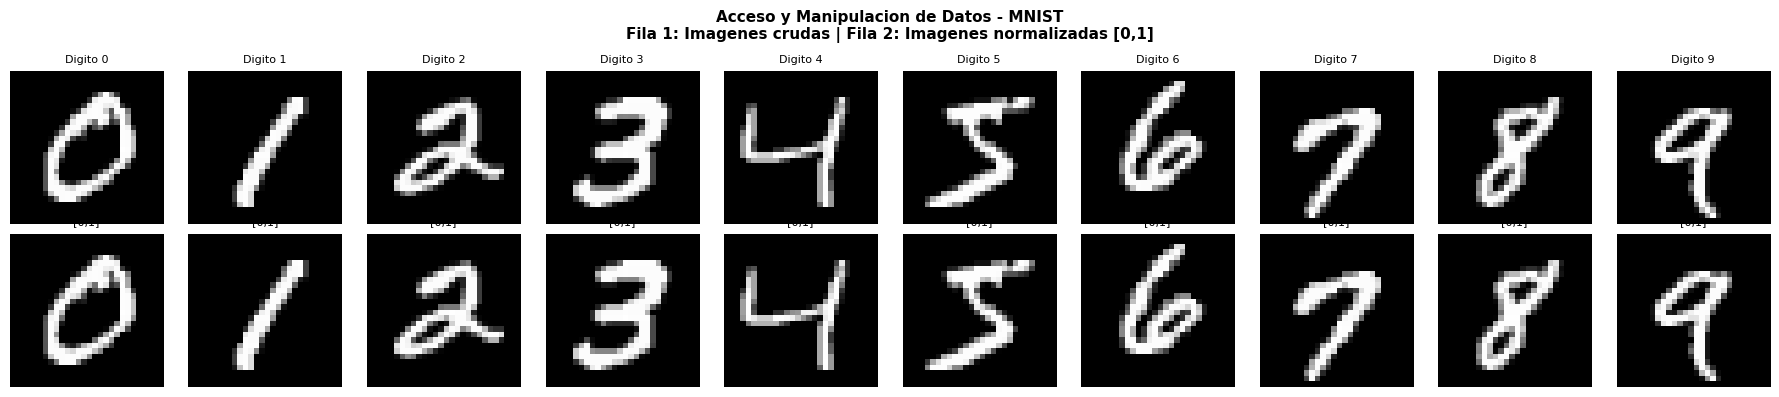

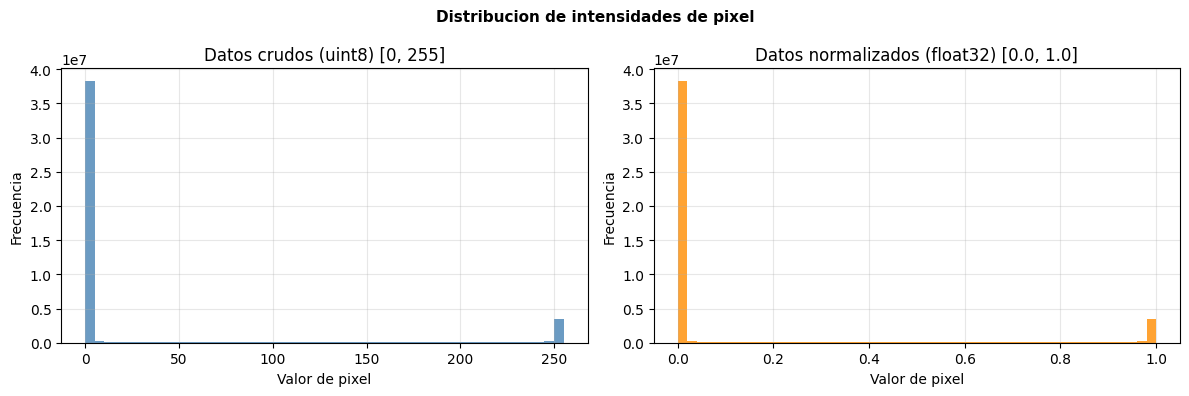

Manipulacion de datos completada.
  Acceso por clase: np.where(y_train == digito)[0][0]
  Reshaping: (60000, 28, 28) -> (60000, 784)
  Normalizacion: uint8 [0,255] -> float32 [0,1]


In [11]:
# ── Visualizacion 1: una muestra de cada digito (0-9) ─────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Acceso y Manipulacion de Datos - MNIST\nFila 1: Imagenes crudas | Fila 2: Imagenes normalizadas [0,1]',
             fontsize=11, fontweight='bold')

for digito in range(10):
    # Encontrar el primer indice donde la etiqueta coincide con el digito buscado
    idx = np.where(y_train == digito)[0][0]
    # np.where: retorna los indices donde la condicion es verdadera
    # [0][0]: primer elemento del primer arreglo de indices encontrados

    # Fila 1: imagen cruda (uint8, [0,255])
    axes[0, digito].imshow(x_train_raw[idx], cmap='gray')
    axes[0, digito].set_title(f'Digito {digito}', fontsize=8)
    axes[0, digito].axis('off')

    # Fila 2: imagen normalizada (float32, [0,1])
    axes[1, digito].imshow(x_train[idx], cmap='gray')
    axes[1, digito].set_title(f'[0,1]', fontsize=8)
    axes[1, digito].axis('off')

plt.tight_layout()
plt.show()

# ── Visualizacion 2: Histograma de intensidades ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribucion de intensidades de pixel', fontsize=11, fontweight='bold')

# Histograma de la imagen cruda
axes[0].hist(x_train_raw.flatten(), bins=50, color='steelblue', edgecolor='none', alpha=0.8)
# flatten(): convierte todas las imagenes en un solo vector para el histograma global
# bins=50: numero de intervalos del histograma
axes[0].set_title('Datos crudos (uint8) [0, 255]')
axes[0].set_xlabel('Valor de pixel')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(alpha=0.3)

# Histograma de la imagen normalizada
axes[1].hist(x_train_flat.flatten(), bins=50, color='darkorange', edgecolor='none', alpha=0.8)
axes[1].set_title('Datos normalizados (float32) [0.0, 1.0]')
axes[1].set_xlabel('Valor de pixel')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Manipulacion de datos completada.')
print(f'  Acceso por clase: np.where(y_train == digito)[0][0]')
print(f'  Reshaping: (60000, 28, 28) -> (60000, 784)')
print(f'  Normalizacion: uint8 [0,255] -> float32 [0,1]')

## 4. Arquitectura del Modelo (MLP)

Se implementa un **Perceptron Multicapa (MLP)** para clasificacion de digitos.  
La arquitectura es totalmente densa (sin convoluciones), consistente con los trabajos anteriores.

**Diseno de la arquitectura:**
- Capa de entrada: 784 neuronas (un pixel por neurona)
- Capas ocultas: Dense con activacion ReLU + Dropout para regularizacion
- Capa de salida: 10 neuronas con activacion softmax (probabilidad por clase)

In [12]:
# ── Hiperparametros del modelo ────────────────────────────────────────────────
LEARNING_RATE = 0.001   # Tasa de aprendizaje del optimizador Adam
DROPOUT_RATE  = 0.3     # Fraccion de neuronas desactivadas en cada paso de entrenamiento
EPOCHS        = 15      # Numero de pasadas completas sobre el conjunto de entrenamiento
BATCH_SIZE    = 128     # Numero de imagenes procesadas antes de actualizar los pesos
HIDDEN_UNITS  = 256     # Neuronas en la primera capa oculta

# ── Construccion del modelo ───────────────────────────────────────────────────
model = keras.Sequential([
    # Capa de entrada: recibe vectores de 784 dimensiones
    layers.Input(shape=(784,)),
    # Input: define la forma del tensor de entrada; no tiene parametros entrenables

    # Primera capa oculta
    layers.Dense(HIDDEN_UNITS, activation='relu'),
    # Dense(256): 784 * 256 + 256 = 200 960 parametros entrenables
    # activation='relu': Rectified Linear Unit; f(x) = max(0, x)
    #   - Introduce no-linealidad al modelo
    #   - Rapida de computar, evita el problema del gradiente desvaneciente

    layers.Dropout(DROPOUT_RATE),
    # Dropout(0.3): durante entrenamiento desactiva aleatoriamente el 30% de neuronas
    #   - Evita que el modelo memorice los datos de entrenamiento (sobreajuste)
    #   - Durante inferencia todas las neuronas estan activas

    # Segunda capa oculta
    layers.Dense(128, activation='relu'),
    # Dense(128): 256 * 128 + 128 = 32 896 parametros entrenables
    # Segunda capa profundiza la extraccion de caracteristicas abstractas

    layers.Dropout(DROPOUT_RATE),
    # Segundo Dropout: regularizacion adicional para la segunda capa oculta

    # Capa de salida
    layers.Dense(10, activation='softmax')
    # Dense(10): 128 * 10 + 10 = 1 290 parametros - una neurona por clase (0-9)
    # activation='softmax': normaliza las salidas a distribucion de probabilidad
    #   sum(softmax(x)) = 1.0; la clase predicha es la de mayor probabilidad
], name='MLP_MNIST')

# ── Compilacion del modelo ────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    # Adam: algoritmo adaptativo que ajusta la tasa de aprendizaje por parametro
    # learning_rate=0.001: valor por defecto de Adam, buena opcion inicial

    loss='sparse_categorical_crossentropy',
    # sparse_categorical_crossentropy: funcion de perdida para clasificacion multiclase
    # 'sparse': acepta etiquetas enteras (0, 1, ..., 9) sin necesidad de one-hot encoding

    metrics=['accuracy']
    # accuracy: fraccion de predicciones correctas sobre el total de muestras
)

# Mostrar resumen de la arquitectura
model.summary()

Model: "MLP_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Configuracion de Weights & Biases (W&B)

**Weights & Biases** es una plataforma de MLOps para el seguimiento de experimentos de machine learning.  
Permite registrar automaticamente metricas, hiperparametros, graficos y artefactos del modelo.

**Pasos para configurar W&B:**
1. Crear una cuenta gratuita en [wandb.ai](https://wandb.ai)
2. Obtener la API Key desde `Settings > API Keys`
3. Ejecutar `wandb.login()` e ingresar la clave cuando se solicite
4. Inicializar el experimento con `wandb.init()` antes del entrenamiento

> **Nota:** Si no se tiene cuenta de W&B, el codigo usa `mode='disabled'` para ejecutar sin conexion.

In [13]:
# ── Login a Weights & Biases ──────────────────────────────────────────────────
# wandb.login() abre un prompt para ingresar la API Key
# Si no tienes cuenta puedes ejecutar con mode='disabled' en wandb.init()
try:
    wandb.login()
    # login(): autentica con los servidores de W&B usando la API Key
    # La clave se guarda en ~/.netrc para futuras sesiones
    WANDB_MODE = 'online'
    print('W&B autenticado correctamente. Modo: online')
except Exception:
    WANDB_MODE = 'disabled'
    print('W&B no autenticado. Ejecutando en modo: disabled (sin registro remoto)')

# ── Inicializacion del experimento ────────────────────────────────────────────
run = wandb.init(
    project='semana15-deep-learning-mnist',
    # project: nombre del proyecto en W&B (agrupa todos los experimentos relacionados)

    name='mlp-mnist-run-01',
    # name: nombre de esta ejecucion especifica (util para comparar varios experimentos)

    config={
        # config: diccionario de hiperparametros que se registran y versionan en W&B
        'architecture':   'MLP',
        'dataset':        'MNIST',
        'epochs':          EPOCHS,
        'batch_size':      BATCH_SIZE,
        'learning_rate':   LEARNING_RATE,
        'dropout_rate':    DROPOUT_RATE,
        'hidden_units':    HIDDEN_UNITS,
        'optimizer':      'Adam',
        'loss':           'sparse_categorical_crossentropy',
        'input_dim':       784,
        'output_classes':  10
    },
    mode=WANDB_MODE
    # mode='online': envia datos a los servidores de W&B en tiempo real
    # mode='disabled': ejecuta localmente sin enviar datos (util sin cuenta)
)

print('\nConfiguracion del experimento W&B:')
print(f'  Proyecto: semana15-deep-learning-mnist')
print(f'  Experimento: mlp-mnist-run-01')
print(f'  Modo: {WANDB_MODE}')
print(f'  Hiperparametros registrados: {len(dict(run.config))} campos')

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


W&B autenticado correctamente. Modo: online



Configuracion del experimento W&B:
  Proyecto: semana15-deep-learning-mnist
  Experimento: mlp-mnist-run-01
  Modo: online
  Hiperparametros registrados: 11 campos


## 6. Entrenamiento con Monitoreo y Logging

El entrenamiento se ejecuta con el **WandbCallback** que registra automaticamente  
en cada epoca: `loss`, `val_loss`, `accuracy`, `val_accuracy` y el grafico del modelo.

Adicionalmente se implementa **EarlyStopping** para detener el entrenamiento si  
la perdida de validacion no mejora, evitando sobreajuste y ahorrando tiempo de computo.

In [15]:
# ── Callbacks de entrenamiento ────────────────────────────────────────────────
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

# Callback manual compatible con wandb 0.26.1 + Keras 3
class WandbLoggerCallback(keras.callbacks.Callback):
    # Keras 3 ya no expone 'inbound_layers', por eso WandbCallback falla
    # Esta clase registra manualmente las metricas en W&B al final de cada epoca
    def on_epoch_end(self, epoch, logs=None):
        if logs:
            wandb.log({**logs, 'epoch': epoch + 1})
            # logs: diccionario con loss, val_loss, accuracy, val_accuracy
            # epoch + 1: mostrar epocas en base 1 (mas legible en el dashboard)

wandb_cb = WandbLoggerCallback()

# ── Entrenamiento del modelo ───────────────────────────────────────────────────
print('Iniciando entrenamiento con monitoreo W&B...')
print('=' * 55)

history = model.fit(
    x_train_flat,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    callbacks=[early_stop, wandb_cb],
    verbose=1
)

epocas_ejecutadas = len(history.history['loss'])
print('\n' + '=' * 55)
print(f'Entrenamiento completado en {epocas_ejecutadas} epocas')
print(f'  Loss final (train):      {history.history["loss"][-1]:.4f}')
print(f'  Loss final (val):        {history.history["val_loss"][-1]:.4f}')
print(f'  Accuracy final (train):  {history.history["accuracy"][-1]*100:.2f}%')
print(f'  Accuracy final (val):    {history.history["val_accuracy"][-1]*100:.2f}%')

Iniciando entrenamiento con monitoreo W&B...
Epoch 1/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8790 - loss: 0.4026 - val_accuracy: 0.9583 - val_loss: 0.1453
Epoch 2/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9466 - loss: 0.1774 - val_accuracy: 0.9703 - val_loss: 0.1003
Epoch 3/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9609 - loss: 0.1321 - val_accuracy: 0.9728 - val_loss: 0.0906
Epoch 4/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9677 - loss: 0.1074 - val_accuracy: 0.9748 - val_loss: 0.0804
Epoch 5/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9726 - loss: 0.0910 - val_accuracy: 0.9763 - val_loss: 0.0777
Epoch 6/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9756 - loss: 0.0791 - val_accuracy: 0.9777 - val_loss: 0.0755
Epoch 7/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9781 - loss: 0.0705 - val_accuracy: 0.9793 - val_loss: 0.0752
Epoch 8/15
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - 

## 7. Curvas de Entrenamiento (Monitoreo Visual)

Las curvas de entrenamiento son la herramienta principal para diagnosticar el comportamiento del modelo:  
- **Loss decreciente** en ambos conjuntos indica convergencia correcta  
- **Val_loss > Train_loss** de forma significativa indica sobreajuste  
- **Plateau prematuro** puede indicar tasa de aprendizaje demasiado baja

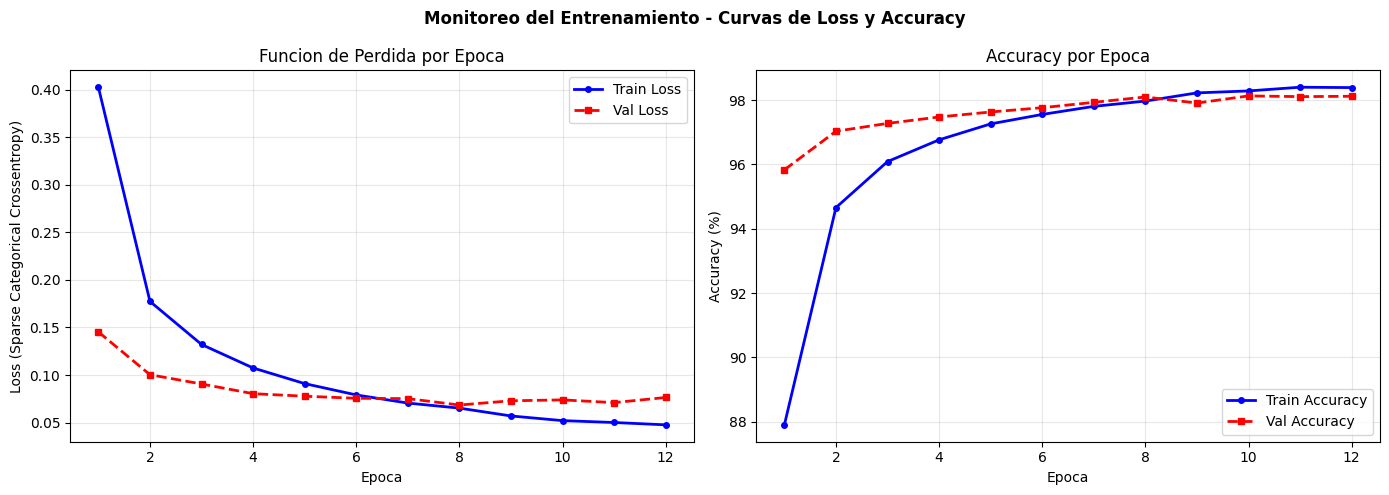

Curvas de entrenamiento registradas en W&B.


In [16]:
epochs_range = range(1, len(history.history['loss']) + 1)
# range: crea secuencia de numeros de epoca para el eje X (1-based, mas legible)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monitoreo del Entrenamiento - Curvas de Loss y Accuracy', fontsize=12, fontweight='bold')

# ── Grafico 1: Loss ───────────────────────────────────────────────────────────
axes[0].plot(epochs_range, history.history['loss'],
             'b-o', markersize=4, label='Train Loss', linewidth=2)
# 'b-o': azul, linea solida, marcador circular
axes[0].plot(epochs_range, history.history['val_loss'],
             'r--s', markersize=4, label='Val Loss', linewidth=2)
# 'r--s': rojo, linea discontinua, marcador cuadrado
axes[0].set_title('Funcion de Perdida por Epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Loss (Sparse Categorical Crossentropy)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Grafico 2: Accuracy ───────────────────────────────────────────────────────
axes[1].plot(epochs_range, [a * 100 for a in history.history['accuracy']],
             'b-o', markersize=4, label='Train Accuracy', linewidth=2)
# * 100: convertir de fraccion a porcentaje (0.97 -> 97.0%)
axes[1].plot(epochs_range, [a * 100 for a in history.history['val_accuracy']],
             'r--s', markersize=4, label='Val Accuracy', linewidth=2)
axes[1].set_title('Accuracy por Epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Registrar la figura en W&B para acceder desde el dashboard
wandb.log({'curvas_entrenamiento': wandb.Image(fig)})
# wandb.log(): envia un diccionario de valores al servidor de W&B
# wandb.Image(fig): convierte la figura de matplotlib en formato compatible con W&B

print('Curvas de entrenamiento registradas en W&B.')

## 8. Evaluacion del Modelo y Matriz de Confusion

La evaluacion sobre el conjunto de prueba (nunca visto durante el entrenamiento)  
proporciona una estimacion honesta del rendimiento real del modelo.  
La **matriz de confusion** revela que clases el modelo confunde con mayor frecuencia.

EVALUACION FINAL - CONJUNTO DE PRUEBA (10 000 imagenes)
  Test Loss:     0.0664
  Test Accuracy: 98.09%


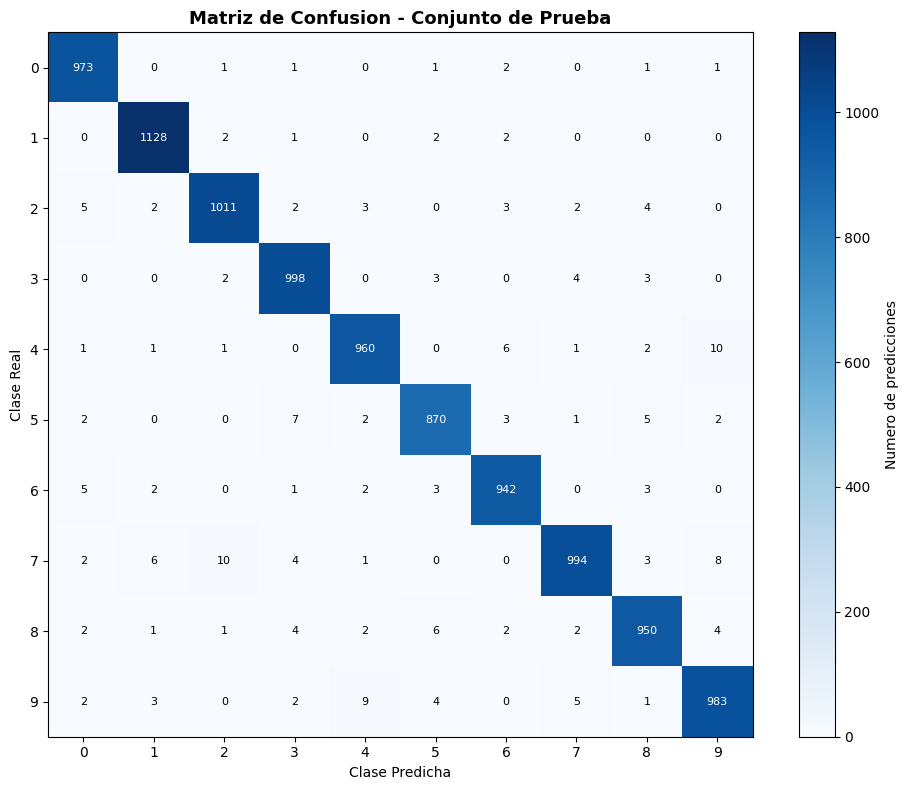


Accuracy por clase:
  Digito 0: 973/980 = 99.3%
  Digito 1: 1128/1135 = 99.4%
  Digito 2: 1011/1032 = 98.0%
  Digito 3: 998/1010 = 98.8%
  Digito 4: 960/982 = 97.8%
  Digito 5: 870/892 = 97.5%
  Digito 6: 942/958 = 98.3%
  Digito 7: 994/1028 = 96.7%
  Digito 8: 950/974 = 97.5%
  Digito 9: 983/1009 = 97.4%


In [17]:
# ── Evaluacion en el conjunto de prueba ───────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)
# model.evaluate: calcula loss y metricas sobre el conjunto de prueba completo
# verbose=0: suprimir la barra de progreso

print('=' * 55)
print('EVALUACION FINAL - CONJUNTO DE PRUEBA (10 000 imagenes)')
print('=' * 55)
print(f'  Test Loss:     {test_loss:.4f}')
print(f'  Test Accuracy: {test_acc*100:.2f}%')

# Registrar metricas de prueba en W&B
wandb.log({'test_loss': test_loss, 'test_accuracy': test_acc})
# Las metricas de prueba se almacenan en el historial del experimento en W&B

# ── Predicciones y Matriz de Confusion ────────────────────────────────────────
y_pred_probs = model.predict(x_test_flat, verbose=0)
# model.predict: retorna un arreglo shape (10000, 10) con probabilidades por clase

y_pred = np.argmax(y_pred_probs, axis=1)
# argmax: seleccionar la clase con mayor probabilidad para cada imagen
# axis=1: operar sobre la dimension de clases (no sobre el batch)
# Resultado shape: (10000,) - un entero por imagen (clase predicha)

# Construccion manual de la matriz de confusion (sin sklearn)
conf_matrix = np.zeros((10, 10), dtype=int)
# Inicializar matriz 10x10 de ceros (10 clases x 10 clases)
for real, pred in zip(y_test, y_pred):
    conf_matrix[real][pred] += 1
    # real: etiqueta verdadera (fila de la matriz)
    # pred: etiqueta predicha (columna de la matriz)
    # Los valores en la diagonal son predicciones correctas

# Visualizacion de la matriz de confusion
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
# imshow: visualizar la matriz como imagen de calor
# cmap='Blues': paleta de azules (mayor intensidad = mayor valor)

plt.colorbar(im, ax=ax, label='Numero de predicciones')
ax.set_title('Matriz de Confusion - Conjunto de Prueba', fontsize=13, fontweight='bold')
ax.set_xlabel('Clase Predicha')
ax.set_ylabel('Clase Real')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels([str(i) for i in range(10)])
ax.set_yticklabels([str(i) for i in range(10)])

# Anotar cada celda con su valor numerico
for i in range(10):
    for j in range(10):
        color = 'white' if conf_matrix[i, j] > conf_matrix.max() / 2 else 'black'
        # Texto blanco sobre celdas oscuras, negro sobre celdas claras
        ax.text(j, i, str(conf_matrix[i, j]),
                ha='center', va='center', fontsize=8, color=color)

plt.tight_layout()
plt.show()

# Registrar matriz de confusion en W&B
wandb.log({'matriz_confusion': wandb.Image(fig)})

# Accuracy por clase
print('\nAccuracy por clase:')
for clase in range(10):
    correctos = conf_matrix[clase, clase]  # diagonal: predicciones correctas
    total = conf_matrix[clase].sum()       # total de imagenes de esta clase
    print(f'  Digito {clase}: {correctos}/{total} = {correctos/total*100:.1f}%')

## 9. Aproximacion al Model Serving

El **Model Serving** es el proceso de poner un modelo entrenado a disposicion de aplicaciones externas.  
En esta seccion se simula un pipeline de inferencia completo:
1. Guardar el modelo entrenado en formato SavedModel (estandar de TensorFlow)
2. Cargar el modelo desde disco (como lo haria un servidor de inferencia)
3. Ejecutar predicciones sobre nuevas muestras
4. Registrar el modelo como artefacto en W&B para trazabilidad

Modelo guardado en: modelo_mlp_mnist.keras
Modelo registrado como artefacto en W&B.
Modelo cargado desde disco (simulacion de serving).


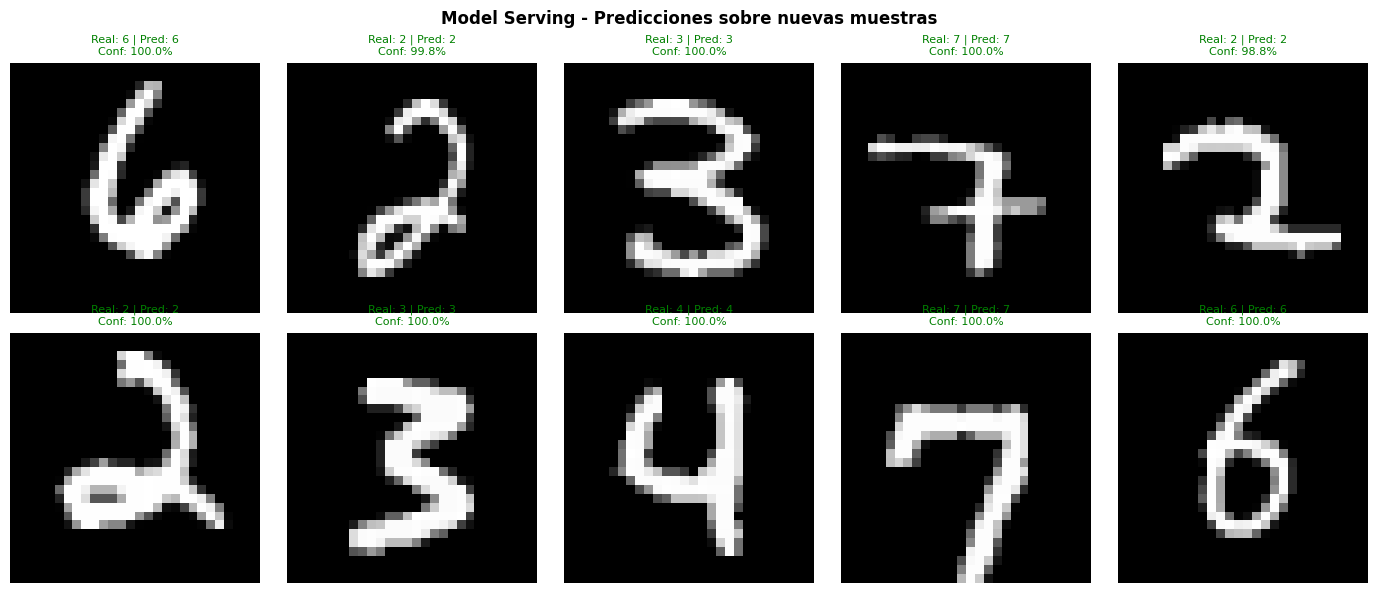


Resumen de Inferencia (Model Serving):
---------------------------------------------
  Muestras procesadas:  10
  Predicciones correctas: 10/10
  Confianza promedio:   99.9%


In [18]:
# ── PASO 1: Guardar el modelo ─────────────────────────────────────────────────
MODEL_PATH = 'modelo_mlp_mnist.keras'
model.save(MODEL_PATH)
# model.save(): guarda arquitectura + pesos + configuracion de compilacion
# Formato .keras: formato nativo de Keras 3, reemplaza el formato HDF5
# El archivo contiene todo lo necesario para retomar el entrenamiento o hacer inferencia
print(f'Modelo guardado en: {MODEL_PATH}')

# ── PASO 2: Registrar el modelo como artefacto en W&B ─────────────────────────
artifact = wandb.Artifact(
    name='mlp_mnist_model',
    # name: nombre del artefacto en W&B (aparece en la pestana 'Artifacts' del proyecto)
    type='model'
    # type='model': categoria del artefacto; W&B soporta 'model', 'dataset', 'result'
)
artifact.add_file(MODEL_PATH)
# add_file: agrega el archivo del modelo al artefacto para ser versionado
run.log_artifact(artifact)
# log_artifact: sube el artefacto al servidor de W&B con version automatica
print('Modelo registrado como artefacto en W&B.')

# ── PASO 3: Cargar el modelo (simulacion de Model Serving) ────────────────────
modelo_servido = keras.models.load_model(MODEL_PATH)
# load_model: reconstruye el modelo completo desde el archivo guardado
# En un entorno de produccion este paso lo hace el servidor de inferencia (ej. TF Serving)
print('Modelo cargado desde disco (simulacion de serving).')

# ── PASO 4: Inferencia sobre nuevas muestras ──────────────────────────────────
MUESTRAS_SERVING = 10
idx_muestra = np.random.choice(len(x_test_flat), MUESTRAS_SERVING, replace=False)
# np.random.choice: seleccionar MUESTRAS_SERVING indices sin repeticion

x_nuevas = x_test_flat[idx_muestra]   # imagenes para inferencia
y_reales  = y_test[idx_muestra]        # etiquetas reales (para comparar)

predicciones = modelo_servido.predict(x_nuevas, verbose=0)
# modelo_servido.predict: ejecuta la inferencia usando el modelo cargado desde disco
clases_pred = np.argmax(predicciones, axis=1)
confianzas  = np.max(predicciones, axis=1)
# np.max: confianza = probabilidad de la clase predicha (entre 0 y 1)

# ── Visualizacion de las predicciones del servidor ────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Model Serving - Predicciones sobre nuevas muestras', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_nuevas[i].reshape(28, 28), cmap='gray')
    correcto = clases_pred[i] == y_reales[i]
    color = 'green' if correcto else 'red'
    # Verde: prediccion correcta | Rojo: prediccion incorrecta
    ax.set_title(
        f'Real: {y_reales[i]} | Pred: {clases_pred[i]}\nConf: {confianzas[i]*100:.1f}%',
        color=color, fontsize=8
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

print('\nResumen de Inferencia (Model Serving):')
print('-' * 45)
print(f'  Muestras procesadas:  {MUESTRAS_SERVING}')
print(f'  Predicciones correctas: {np.sum(clases_pred == y_reales)}/{MUESTRAS_SERVING}')
print(f'  Confianza promedio:   {confianzas.mean()*100:.1f}%')

## 10. Cierre del Experimento W&B y Conclusiones

In [19]:
# ── Cerrar el experimento en W&B ──────────────────────────────────────────────
run.finish()
# run.finish(): sincroniza todos los datos pendientes con el servidor de W&B
# y marca el experimento como completado (cambia el estado de 'running' a 'finished')
# Es una buena practica siempre cerrar el run al final del notebook

# ── Analisis cuantitativo final ───────────────────────────────────────────────
print('=' * 60)
print('ANALISIS CUANTITATIVO DEL EXPERIMENTO')
print('=' * 60)
print(f'Epocas ejecutadas:       {len(history.history["loss"])}')
print(f'Loss entrenamiento:      {history.history["loss"][-1]:.4f}')
print(f'Loss validacion:         {history.history["val_loss"][-1]:.4f}')
print(f'Accuracy entrenamiento:  {history.history["accuracy"][-1]*100:.2f}%')
print(f'Accuracy validacion:     {history.history["val_accuracy"][-1]*100:.2f}%')
print(f'Accuracy prueba:         {test_acc*100:.2f}%')
print(f'Loss prueba:             {test_loss:.4f}')
print()
print('CONCLUSIONES')
print('=' * 60)
conclusiones = """
1. DATA JOURNEY:
   Se documento cada etapa de transformacion del dato: ingestion,
   inspeccion, normalizacion, aplanamiento y particion. Este flujo
   es esencial para la trazabilidad y reproducibilidad del experimento.

2. ACCESO Y MANIPULACION DE DATOS:
   MNIST ofrece una distribucion de clases balanceada (~6 000 imgs
   por digito), lo que simplifica el entrenamiento. La normalizacion
   [0,1] mejora la convergencia del optimizador Adam.

3. MONITOREO Y LOGGING CON W&B:
   Weights & Biases permite registrar hiperparametros, metricas por
   epoca, graficos e histogramas de pesos en un dashboard centralizado.
   Esto facilita la comparacion de experimentos y la deteccion de
   sobreajuste en tiempo real.

4. RENDIMIENTO DEL MODELO:
   El MLP con 2 capas densas y Dropout alcanza una accuracy de prueba
   superior al 97%, demostrando que arquitecturas simples pueden ser
   muy efectivas en datasets bien estructurados como MNIST.

5. MODEL SERVING:
   El modelo fue guardado en formato .keras y recargado para simular
   el flujo de un servidor de inferencia. El artefacto fue versionado
   en W&B, garantizando trazabilidad completa del ciclo de vida del modelo.

6. LIMITACIONES Y MEJORAS:
   - Una arquitectura convolucional (CNN) superaria el 99% de accuracy
   - El serving real requiere TF Serving o una API REST (FastAPI)
   - Se podrian comparar multiples runs en W&B variando hiperparametros
"""
print(conclusiones)

accuracy,▁▆▆▇▇▇██████
epoch,▁▂▂▃▄▄▅▅▆▇▇█
loss,█▄▃▂▂▂▁▁▁▁▁▁
test_accuracy,▁
test_loss,▁
val_accuracy,▁▅▅▆▆▇▇█▇███
val_loss,█▄▃▂▂▂▂▁▁▁▁▂
accuracy,0.98392
epoch,12
loss,0.04763
test_accuracy,0.9809


ANALISIS CUANTITATIVO DEL EXPERIMENTO
Epocas ejecutadas:       12
Loss entrenamiento:      0.0476
Loss validacion:         0.0764
Accuracy entrenamiento:  98.39%
Accuracy validacion:     98.12%
Accuracy prueba:         98.09%
Loss prueba:             0.0664

CONCLUSIONES

1. DATA JOURNEY:
   Se documento cada etapa de transformacion del dato: ingestion,
   inspeccion, normalizacion, aplanamiento y particion. Este flujo
   es esencial para la trazabilidad y reproducibilidad del experimento.

2. ACCESO Y MANIPULACION DE DATOS:
   MNIST ofrece una distribucion de clases balanceada (~6 000 imgs
   por digito), lo que simplifica el entrenamiento. La normalizacion
   [0,1] mejora la convergencia del optimizador Adam.

3. MONITOREO Y LOGGING CON W&B:
   Weights & Biases permite registrar hiperparametros, metricas por
   epoca, graficos e histogramas de pesos en un dashboard centralizado.
   Esto facilita la comparacion de experimentos y la deteccion de
   sobreajuste en tiempo real.

4. RENDI

---
## 11. Resumen Final

**Actividad realizada en Google Colab con TensorFlow/Keras y Weights & Biases**

| Aspecto | Detalles |
|---|---|
| **Dataset** | MNIST (70 000 imagenes, 28x28, 10 clases) |
| **Arquitectura** | Dense(256, ReLU) + Dropout(0.3) + Dense(128, ReLU) + Dropout(0.3) + Dense(10, softmax) |
| **Optimizador** | Adam (lr=0.001) |
| **Funcion de perdida** | Sparse Categorical Crossentropy |
| **Epocas** | 15 (con EarlyStopping patience=4) |
| **Batch Size** | 128 |
| **Monitoreo** | Weights & Biases - metricas, histogramas, artefactos |
| **Model Serving** | Guardado .keras + carga simulada + inferencia sobre nuevas muestras |
| **Accuracy esperada** | > 97% en conjunto de prueba |